# BR-101 EDA Runbook: Step 7

This notebook-style script consumes the artifacts generated by
previous EDA steps and performs the categorical EDA
requested in runbook step 7 for occurrence-level data only.

Inputs expected under `data/silver/eda_runbook`:
- `canonical_accidents.parquet`
- `manual_exclusions.parquet`

Outputs written back to the same artifact directory:
- category summaries
- grouped plot inputs
- model-ready aggregate tables
- GLM coefficient tables


In [1]:
from pathlib import Path
from datetime import timedelta

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)


def resolve_project_root() -> Path:
    candidates: list[Path] = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parents[1])

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, cwd.parent])

    for candidate in candidates:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Could not resolve the project root.")


PROJECT_ROOT = resolve_project_root()
ARTIFACTS_DIR = PROJECT_ROOT / "data" / "silver" / "eda_runbook"

CATEGORY_ORDER_HINTS = {
    "dia_semana": [
        "segunda-feira",
        "terça-feira",
        "quarta-feira",
        "quinta-feira",
        "sexta-feira",
        "sábado",
        "domingo",
        "unknown",
    ],
    "fase_dia": [
        "Amanhecer",
        "Pleno dia",
        "Anoitecer",
        "Plena Noite",
        "unknown",
    ],
    "condicao_metereologica": [
        "Céu Claro",
        "Sol",
        "Nublado",
        "Chuva",
        "Garoa/Chuvisco",
        "Nevoeiro/Neblina",
        "Vento",
        "Granizo",
        "Neve",
        "Ignorado",
        "unknown",
    ],
    "holiday_status": [
        "regular_day",
        "holiday_eve",
        "holiday",
        "day_after_holiday",
        "unknown",
    ],
    "month": list(range(1, 13)),
}
CATEGORY_COLUMNS = list(CATEGORY_ORDER_HINTS)
MODEL_FEATURE_COLUMNS = CATEGORY_COLUMNS + ["year", "uf"]

COUNT_LEVEL_MIN_ACCIDENTS = 250
SEVERITY_LEVEL_MIN_PEOPLE = 1000
STRONG_PVALUE_THRESHOLD = 0.01
MODERATE_PVALUE_THRESHOLD = 0.05
STRONG_EFFECT_THRESHOLD = 0.15
MODERATE_EFFECT_THRESHOLD = 0.05
SPARSE_LEVEL_SHARE_THRESHOLD = 0.40

sns.set_theme(style="whitegrid")

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
except ImportError:
    sm = None
    smf = None


def save_frame(df: pd.DataFrame, name: str, *, index: bool = False) -> None:
    parquet_path = ARTIFACTS_DIR / f"{name}.parquet"
    csv_path = ARTIFACTS_DIR / f"{name}.csv"
    df.to_parquet(parquet_path, index=index)
    df.to_csv(csv_path, index=index)


def apply_manual_exclusions(
    df: pd.DataFrame,
    exclusions: pd.DataFrame,
    *,
    column_name: str,
) -> pd.DataFrame:
    active = exclusions.loc[exclusions[column_name].fillna(False), ["uf", "year", column_name]].copy()
    active[column_name] = True
    merged = df.merge(active, on=["uf", "year"], how="left")
    exclusion_mask = merged[column_name].fillna(False).to_numpy(dtype=bool)
    return merged.loc[~exclusion_mask].drop(columns=[column_name], errors="ignore")


def build_holiday_lookup(df: pd.DataFrame) -> pd.DataFrame:
    lookup = df[["uf", "accident_date"]].dropna().drop_duplicates().copy()
    cache: dict[tuple[str, int], holidays.HolidayBase] = {}

    def classify(row: pd.Series) -> str:
        uf = str(row["uf"])
        date_value = row["accident_date"]
        cache_key = (uf, date_value.year)
        if cache_key not in cache:
            cache[cache_key] = holidays.Brazil(years=[date_value.year], subdiv=uf)

        holiday_calendar = cache[cache_key]
        if date_value in holiday_calendar:
            return "holiday"
        if date_value + timedelta(days=1) in holiday_calendar:
            return "holiday_eve"
        if date_value - timedelta(days=1) in holiday_calendar:
            return "day_after_holiday"
        return "regular_day"

    lookup["holiday_status"] = lookup.apply(classify, axis=1)
    return lookup


def category_value_label(category: str, value: object) -> str:
    if pd.isna(value):
        return "missing"
    if category == "month":
        try:
            return f"{int(float(value)):02d}"
        except (TypeError, ValueError):
            return str(value)
    return str(value)


def get_category_levels(df: pd.DataFrame, category: str) -> list[object]:
    observed = df[category].dropna().unique().tolist()
    hinted = list(CATEGORY_ORDER_HINTS.get(category, []))
    extras = sorted([value for value in observed if value not in hinted], key=str)
    return hinted + extras


def choose_reference_categories(df: pd.DataFrame, category_columns: list[str]) -> dict[str, object]:
    references: dict[str, object] = {}
    for category in category_columns:
        value_counts = df[category].dropna().value_counts()
        if not value_counts.empty:
            references[category] = value_counts.index[0]
    return references


def summarize_by_category(
    df: pd.DataFrame,
    category: str,
    levels: list[object],
) -> pd.DataFrame:
    summary = (
        df.groupby(category, dropna=False)
        .agg(
            accident_count=("id", "size"),
            fatal_victims=("mortos", "sum"),
            people_involved=("pessoas", "sum"),
            fatal_accident_count=("has_fatality_occ", "sum"),
        )
        .reset_index()
    )

    summary = pd.DataFrame({category: levels}).merge(summary, on=category, how="left")
    for column in ["accident_count", "fatal_victims", "people_involved", "fatal_accident_count"]:
        summary[column] = pd.to_numeric(summary[column], errors="coerce").fillna(0)

    summary["variable"] = category
    summary["level_label"] = summary[category].map(lambda value: category_value_label(category, value))
    summary["level_observed"] = summary["accident_count"].gt(0)
    summary["fatal_victim_share"] = np.where(
        summary["people_involved"] > 0,
        summary["fatal_victims"] / summary["people_involved"],
        np.nan,
    )
    summary["fatal_accident_share"] = np.where(
        summary["accident_count"] > 0,
        summary["fatal_accident_count"] / summary["accident_count"],
        np.nan,
    )
    return summary[
        [
            "variable",
            "level_label",
            "level_observed",
            category,
            "accident_count",
            "fatal_victims",
            "people_involved",
            "fatal_accident_count",
            "fatal_victim_share",
            "fatal_accident_share",
        ]
    ]


def summarize_by_category_and_year(
    df: pd.DataFrame,
    category: str,
    levels: list[object],
) -> pd.DataFrame:
    grouped = (
        df.groupby(["year", category], dropna=False)
        .agg(
            accident_count=("id", "size"),
            fatal_victims=("mortos", "sum"),
            people_involved=("pessoas", "sum"),
            fatal_accident_count=("has_fatality_occ", "sum"),
        )
        .reset_index()
    )

    year_levels = sorted(pd.to_numeric(df["year"], errors="coerce").dropna().astype(int).unique().tolist())
    complete_index = pd.MultiIndex.from_product([year_levels, levels], names=["year", category])
    grouped = grouped.set_index(["year", category]).reindex(complete_index).reset_index()

    for column in ["accident_count", "fatal_victims", "people_involved", "fatal_accident_count"]:
        grouped[column] = pd.to_numeric(grouped[column], errors="coerce").fillna(0)

    grouped["variable"] = category
    grouped["level_label"] = grouped[category].map(lambda value: category_value_label(category, value))
    grouped["level_observed"] = grouped["accident_count"].gt(0)
    grouped["fatal_victim_share"] = np.where(
        grouped["people_involved"] > 0,
        grouped["fatal_victims"] / grouped["people_involved"],
        np.nan,
    )
    grouped["fatal_accident_share"] = np.where(
        grouped["accident_count"] > 0,
        grouped["fatal_accident_count"] / grouped["accident_count"],
        np.nan,
    )
    return grouped


def prepare_statsmodels_frame(
    df: pd.DataFrame,
    category_columns: list[str],
    category_levels: dict[str, list[object]],
    reference_categories: dict[str, object],
) -> pd.DataFrame:
    prepared = df.copy()
    prepared = prepared.dropna(subset=["uf", "year", *category_columns])

    prepared["year"] = pd.to_numeric(prepared["year"], errors="coerce")
    prepared = prepared.dropna(subset=["year"])
    prepared["year"] = prepared["year"].astype("int64")
    prepared["uf"] = prepared["uf"].astype(str)

    for category in category_columns:
        if category == "month":
            prepared[category] = pd.to_numeric(prepared[category], errors="coerce")
            prepared = prepared.dropna(subset=[category])
            prepared[category] = prepared[category].astype("int64")
        else:
            prepared[category] = prepared[category].astype(str)

        observed_levels = [
            value
            for value in category_levels[category]
            if value in prepared[category].dropna().unique().tolist()
        ]
        if not observed_levels:
            continue

        reference = reference_categories.get(category, observed_levels[0])
        if reference not in observed_levels:
            reference = observed_levels[0]
        ordered_levels = [reference] + [value for value in observed_levels if value != reference]
        prepared[category] = pd.Categorical(prepared[category], categories=ordered_levels, ordered=True)

    for column in [
        "accident_count",
        "fatal_victims",
        "people_involved",
        "fatal_accident_count",
        "fatal_victim_share",
        "fatal_accident_share",
    ]:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")

    return prepared


def build_level_support_table(
    df: pd.DataFrame,
    category_columns: list[str],
    category_levels: dict[str, list[object]],
) -> pd.DataFrame:
    records: list[pd.DataFrame] = []
    for category in category_columns:
        grouped = (
            df.groupby(category, dropna=False)
            .agg(
                grouped_cells=("uf", "size"),
                total_accidents=("accident_count", "sum"),
                total_people_involved=("people_involved", "sum"),
            )
            .reset_index()
        )
        grouped = pd.DataFrame({category: category_levels[category]}).merge(grouped, on=category, how="left")
        grouped["variable"] = category
        grouped["level_label"] = grouped[category].map(lambda value: category_value_label(category, value))
        grouped["is_observed"] = pd.to_numeric(grouped["grouped_cells"], errors="coerce").fillna(0).gt(0)
        for column in ["grouped_cells", "total_accidents", "total_people_involved"]:
            grouped[column] = pd.to_numeric(grouped[column], errors="coerce").fillna(0)
        records.append(
            grouped[
                [
                    "variable",
                    category,
                    "level_label",
                    "is_observed",
                    "grouped_cells",
                    "total_accidents",
                    "total_people_involved",
                ]
            ]
        )

    return pd.concat(records, ignore_index=True)


def build_encoding_audit(
    glm_model_frame: pd.DataFrame,
    category_columns: list[str],
    category_levels: dict[str, list[object]],
    reference_categories: dict[str, object],
    level_support: pd.DataFrame,
) -> pd.DataFrame:
    encoding_frame = glm_model_frame[category_columns].copy()
    for category in category_columns:
        encoding_frame[category] = encoding_frame[category].map(
            lambda value, current_category=category: category_value_label(current_category, value)
        )

    dummy_frame = pd.get_dummies(
        encoding_frame,
        columns=category_columns,
        prefix_sep="=",
        drop_first=True,
        dtype=int,
    )
    encoded_columns = set(dummy_frame.columns)

    records: list[dict[str, object]] = []
    for category in category_columns:
        observed_labels = set(
            glm_model_frame[category]
            .dropna()
            .map(lambda value, current_category=category: category_value_label(current_category, value))
            .tolist()
        )
        reference_value = reference_categories.get(category)
        reference_label = (
            category_value_label(category, reference_value) if reference_value is not None else None
        )

        for level in category_levels[category]:
            level_label = category_value_label(category, level)
            if level_label not in observed_labels:
                encoding_status = "expected_but_unobserved"
            elif reference_label is not None and level_label == reference_label:
                encoding_status = "reference_dropped"
            elif f"{category}={level_label}" in encoded_columns:
                encoding_status = "encoded_dummy"
            else:
                encoding_status = "not_encoded"

            records.append(
                {
                    "variable": category,
                    "level_label": level_label,
                    "reference_level_label": reference_label,
                    "encoding_status": encoding_status,
                }
            )

    audit = pd.DataFrame(records)
    audit = audit.merge(
        level_support[
            [
                "variable",
                "level_label",
                "is_observed",
                "grouped_cells",
                "total_accidents",
                "total_people_involved",
            ]
        ],
        on=["variable", "level_label"],
        how="left",
    )
    audit["is_observed"] = audit["is_observed"].fillna(False)
    for column in ["grouped_cells", "total_accidents", "total_people_involved"]:
        audit[column] = pd.to_numeric(audit[column], errors="coerce").fillna(0)

    return audit.sort_values(["variable", "encoding_status", "level_label"]).reset_index(drop=True)


def find_first_column(df: pd.DataFrame, candidates: list[str]) -> str:
    for column in candidates:
        if column in df.columns:
            return column
    raise KeyError(f"None of the expected columns {candidates} were found.")


def parse_model_coefficients(
    coefficients: pd.DataFrame,
    category_columns: list[str],
) -> pd.DataFrame:
    coef_col = find_first_column(coefficients, ["Coef.", "coef"])
    pvalue_col = find_first_column(coefficients, ["P>|z|", "P>|t|", "P>|Chi|"])

    parsed_frames: list[pd.DataFrame] = []
    for category in category_columns:
        feature_terms = coefficients.loc[
            coefficients["term"].astype(str).str.startswith(f"C({category})[", na=False)
        ].copy()
        if feature_terms.empty:
            continue

        raw_levels = feature_terms["term"].astype(str).str.extract(r"\[T\.(.*)\]$")[0]
        feature_terms["variable"] = category
        feature_terms["level_label"] = raw_levels.map(
            lambda value, current_category=category: category_value_label(current_category, value)
        )
        feature_terms["coefficient"] = pd.to_numeric(feature_terms[coef_col], errors="coerce")
        feature_terms["pvalue"] = pd.to_numeric(feature_terms[pvalue_col], errors="coerce")
        feature_terms["abs_pct_change_vs_reference"] = np.abs(np.exp(feature_terms["coefficient"]) - 1)
        parsed_frames.append(
            feature_terms[
                [
                    "variable",
                    "level_label",
                    "term",
                    "coefficient",
                    "pvalue",
                    "abs_pct_change_vs_reference",
                ]
            ]
        )

    if not parsed_frames:
        return pd.DataFrame(
            columns=[
                "variable",
                "level_label",
                "term",
                "coefficient",
                "pvalue",
                "abs_pct_change_vs_reference",
            ]
        )

    return pd.concat(parsed_frames, ignore_index=True)


def augment_coefficient_table(
    coefficients: pd.DataFrame,
    encoding_audit: pd.DataFrame,
    category_columns: list[str],
) -> pd.DataFrame:
    parsed_coefficients = parse_model_coefficients(coefficients, category_columns)
    expanded = encoding_audit.merge(
        parsed_coefficients,
        on=["variable", "level_label"],
        how="left",
    )
    return expanded.sort_values(["variable", "encoding_status", "level_label"]).reset_index(drop=True)


def candidate_score(candidate_tier: str) -> int:
    return {"low": 0, "weak": 1, "moderate": 2, "strong": 3}[candidate_tier]


def classify_feature_candidate(
    significant_levels_p01: int,
    significant_levels_p05: int,
    max_abs_pct_change: float,
    sparse_level_share: float,
) -> str:
    sparse_level_share = 0.0 if pd.isna(sparse_level_share) else float(sparse_level_share)
    max_abs_pct_change = 0.0 if pd.isna(max_abs_pct_change) else float(max_abs_pct_change)

    if (
        significant_levels_p01 > 0
        and max_abs_pct_change >= STRONG_EFFECT_THRESHOLD
        and sparse_level_share <= SPARSE_LEVEL_SHARE_THRESHOLD
    ):
        return "strong"
    if significant_levels_p05 > 0 and max_abs_pct_change >= MODERATE_EFFECT_THRESHOLD:
        return "moderate"
    if significant_levels_p05 > 0 or max_abs_pct_change >= MODERATE_EFFECT_THRESHOLD:
        return "weak"
    return "low"


def build_feature_candidate_summary(
    expanded_coefficients: pd.DataFrame,
    encoding_audit: pd.DataFrame,
    *,
    outcome_label: str,
) -> pd.DataFrame:
    support_column = "total_accidents" if outcome_label == "count" else "total_people_involved"
    min_support = COUNT_LEVEL_MIN_ACCIDENTS if outcome_label == "count" else SEVERITY_LEVEL_MIN_PEOPLE
    records: list[dict[str, object]] = []

    for category in CATEGORY_COLUMNS:
        feature_coefficients = expanded_coefficients.loc[
            expanded_coefficients["variable"].eq(category)
            & expanded_coefficients["encoding_status"].eq("encoded_dummy")
        ].copy()
        feature_audit = encoding_audit.loc[encoding_audit["variable"].eq(category)].copy()
        observed_levels = feature_audit.loc[feature_audit["is_observed"]].copy()

        sparse_level_share = np.nan
        if not observed_levels.empty:
            sparse_level_share = (observed_levels[support_column] < min_support).mean()

        pvalues = pd.to_numeric(feature_coefficients["pvalue"], errors="coerce")
        max_abs_pct_change = pd.to_numeric(
            feature_coefficients["abs_pct_change_vs_reference"],
            errors="coerce",
        ).max()
        if pd.isna(max_abs_pct_change):
            max_abs_pct_change = 0.0

        significant_levels_p01 = int((pvalues < STRONG_PVALUE_THRESHOLD).sum())
        significant_levels_p05 = int((pvalues < MODERATE_PVALUE_THRESHOLD).sum())
        candidate_tier = classify_feature_candidate(
            significant_levels_p01,
            significant_levels_p05,
            max_abs_pct_change,
            sparse_level_share,
        )

        reference_levels = feature_audit["reference_level_label"].dropna().unique().tolist()
        records.append(
            {
                "variable": category,
                f"{outcome_label}_reference_level": reference_levels[0] if reference_levels else None,
                f"{outcome_label}_observed_levels": int(observed_levels.shape[0]),
                f"{outcome_label}_dummy_levels": int(
                    feature_audit["encoding_status"].eq("encoded_dummy").sum()
                ),
                f"{outcome_label}_unobserved_expected_levels": int(
                    feature_audit["encoding_status"].eq("expected_but_unobserved").sum()
                ),
                f"{outcome_label}_significant_levels_p01": significant_levels_p01,
                f"{outcome_label}_significant_levels_p05": significant_levels_p05,
                f"{outcome_label}_max_abs_pct_change_vs_reference": float(max_abs_pct_change),
                f"{outcome_label}_sparse_level_share": (
                    float(sparse_level_share) if not pd.isna(sparse_level_share) else 0.0
                ),
                f"{outcome_label}_candidate_tier": candidate_tier,
                f"{outcome_label}_candidate_score": candidate_score(candidate_tier),
            }
        )

    return pd.DataFrame(records).sort_values(
        [f"{outcome_label}_candidate_score", f"{outcome_label}_max_abs_pct_change_vs_reference"],
        ascending=False,
    ).reset_index(drop=True)


def build_overall_candidate_ranking(
    count_summary: pd.DataFrame,
    severity_summary: pd.DataFrame,
) -> pd.DataFrame:
    ranking = count_summary.merge(severity_summary, on="variable", how="outer")
    ranking["reference_level"] = ranking["count_reference_level"].fillna(
        ranking["severity_reference_level"]
    )
    ranking["overall_candidate_score"] = ranking["count_candidate_score"].fillna(0) + ranking[
        "severity_candidate_score"
    ].fillna(0)
    ranking["overall_candidate_tier"] = np.select(
        [
            ranking["overall_candidate_score"] >= 5,
            ranking["overall_candidate_score"] >= 3,
            ranking["overall_candidate_score"] >= 1,
        ],
        ["high_priority", "promising", "watchlist"],
        default="low_priority",
    )
    ranking["automatic_conclusion"] = np.select(
        [
            ranking["overall_candidate_score"] >= 5,
            ranking["overall_candidate_score"] >= 3,
            ranking["overall_candidate_score"] >= 1,
        ],
        [
            "retain for both count and severity models",
            "retain selectively and check sparse levels before production use",
            "borderline signal; keep only with domain justification",
        ],
        default="low-priority covariate candidate",
    )
    return ranking.sort_values(
        ["overall_candidate_score", "count_candidate_score", "severity_candidate_score"],
        ascending=False,
    ).reset_index(drop=True)


## Load step 1-6 artifacts and apply manual exclusions

In [2]:
canonical_accidents = pd.read_parquet(ARTIFACTS_DIR / "canonical_accidents.parquet")
manual_exclusions = pd.read_parquet(ARTIFACTS_DIR / "manual_exclusions.parquet")

print(f"Canonical accidents loaded: {len(canonical_accidents):,}")
print(f"Manual exclusion rows loaded: {len(manual_exclusions):,}")

Canonical accidents loaded: 106,254
Manual exclusion rows loaded: 270


In [3]:
analysis_df = canonical_accidents.copy()
analysis_df["timestamp"] = pd.to_datetime(analysis_df["timestamp"], errors="coerce")
analysis_df["accident_date"] = analysis_df["timestamp"].dt.date
analysis_df["year"] = pd.to_numeric(analysis_df["year"], errors="coerce").astype("Int64")
analysis_df["month"] = analysis_df["timestamp"].dt.month.astype("Int64")
analysis_df["mortos"] = pd.to_numeric(analysis_df["mortos"], errors="coerce").fillna(0)
analysis_df["pessoas"] = pd.to_numeric(analysis_df["pessoas"], errors="coerce").fillna(0)
analysis_df["fatal_victims_occ"] = pd.to_numeric(
    analysis_df["fatal_victims_occ"], errors="coerce"
).fillna(0)
analysis_df["has_fatality_occ"] = analysis_df["mortos"].gt(0)

analysis_df = apply_manual_exclusions(
    analysis_df,
    manual_exclusions,
    column_name="exclude_from_descriptive",
)

print(f"Accidents retained for step 7 descriptive EDA: {len(analysis_df):,}")

Accidents retained for step 7 descriptive EDA: 103,248


## Derive holiday status, month seasonality, and clean the core categorical variables

In [4]:
holiday_lookup = build_holiday_lookup(analysis_df)
analysis_df = analysis_df.merge(holiday_lookup, on=["uf", "accident_date"], how="left")
analysis_df["holiday_status"] = analysis_df["holiday_status"].fillna("unknown")

for column in ["dia_semana", "fase_dia", "condicao_metereologica"]:
    analysis_df[column] = analysis_df[column].astype("string").str.strip()
    analysis_df[column] = analysis_df[column].fillna("unknown").replace({"<NA>": "unknown"})

analysis_df["month"] = pd.to_numeric(analysis_df["month"], errors="coerce").astype("Int64")
analysis_df["fatal_victim_share_in_accident"] = np.where(
    analysis_df["pessoas"] > 0,
    analysis_df["mortos"] / analysis_df["pessoas"],
    np.nan,
)

category_levels = {
    category: get_category_levels(analysis_df, category) for category in CATEGORY_COLUMNS
}
category_level_review = pd.DataFrame(
    [
        {
            "variable": category,
            "observed_levels": int(analysis_df[category].nunique(dropna=True)),
            "expected_levels_considered": len(levels),
            "ordered_levels": " | ".join(
                category_value_label(category, value) for value in levels
            ),
        }
        for category, levels in category_levels.items()
    ]
)
save_frame(category_level_review, "step7_category_level_review")

category_level_review

,variable,observed_levels,expected_levels_considered,ordered_levels
0,dia_semana,7,8,segunda-feira | terça-feira | quarta-feira | q...
1,fase_dia,4,5,Amanhecer | Pleno dia | Anoitecer | Plena Noit...
2,condicao_metereologica,10,11,Céu Claro | Sol | Nublado | Chuva | Garoa/Chuv...
3,holiday_status,4,5,regular_day | holiday_eve | holiday | day_afte...
4,month,12,12,01 | 02 | 03 | 04 | 05 | 06 | 07 | 08 | 09 | 1...


## One-way summaries for the main categorical variables, including month as a seasonality proxy

In [5]:
category_summaries = pd.concat(
    [
        summarize_by_category(analysis_df, category, category_levels[category])
        for category in CATEGORY_COLUMNS
    ],
    ignore_index=True,
)
save_frame(category_summaries, "step7_category_summaries")

category_summaries[
    [
        "variable",
        "level_label",
        "level_observed",
        "accident_count",
        "fatal_victim_share",
        "fatal_accident_share",
    ]
].head(25)

,variable,level_label,level_observed,accident_count,fatal_victim_share,fatal_accident_share
0,dia_semana,segunda-feira,True,14623.0,0.022886,0.048348
1,dia_semana,terça-feira,True,13047.0,0.020915,0.044915
2,dia_semana,quarta-feira,True,13229.0,0.021712,0.045053
3,dia_semana,quinta-feira,True,13778.0,0.022303,0.045217
4,dia_semana,sexta-feira,True,16091.0,0.022273,0.047977
5,dia_semana,sábado,True,16575.0,0.027591,0.057979
6,dia_semana,domingo,True,15905.0,0.029279,0.061616
7,dia_semana,unknown,False,0.0,NaN,NaN
8,fase_dia,Amanhecer,True,4134.0,0.042521,0.082729
9,fase_dia,Pleno dia,True,58400.0,0.015463,0.032072


## Time-sliced summaries for descriptive plotting

In [6]:
category_year_summaries = pd.concat(
    [
        summarize_by_category_and_year(analysis_df, category, category_levels[category])
        for category in CATEGORY_COLUMNS
    ],
    ignore_index=True,
)
save_frame(category_year_summaries, "step7_category_year_summaries")

category_year_summaries[
    [
        "year",
        "variable",
        "level_label",
        "level_observed",
        "accident_count",
        "fatal_victim_share",
    ]
].head(25)

,year,variable,level_label,level_observed,accident_count,fatal_victim_share
0,2017,dia_semana,segunda-feira,True,1814.0,0.024927
1,2017,dia_semana,terça-feira,True,1585.0,0.015838
2,2017,dia_semana,quarta-feira,True,1578.0,0.022400
3,2017,dia_semana,quinta-feira,True,1776.0,0.022744
4,2017,dia_semana,sexta-feira,True,1987.0,0.022083
5,2017,dia_semana,sábado,True,2265.0,0.029879
6,2017,dia_semana,domingo,True,2163.0,0.029006
7,2017,dia_semana,unknown,False,0.0,NaN
8,2018,dia_semana,segunda-feira,True,1475.0,0.020827
9,2018,dia_semana,terça-feira,True,1310.0,0.025254


## First-pass plots

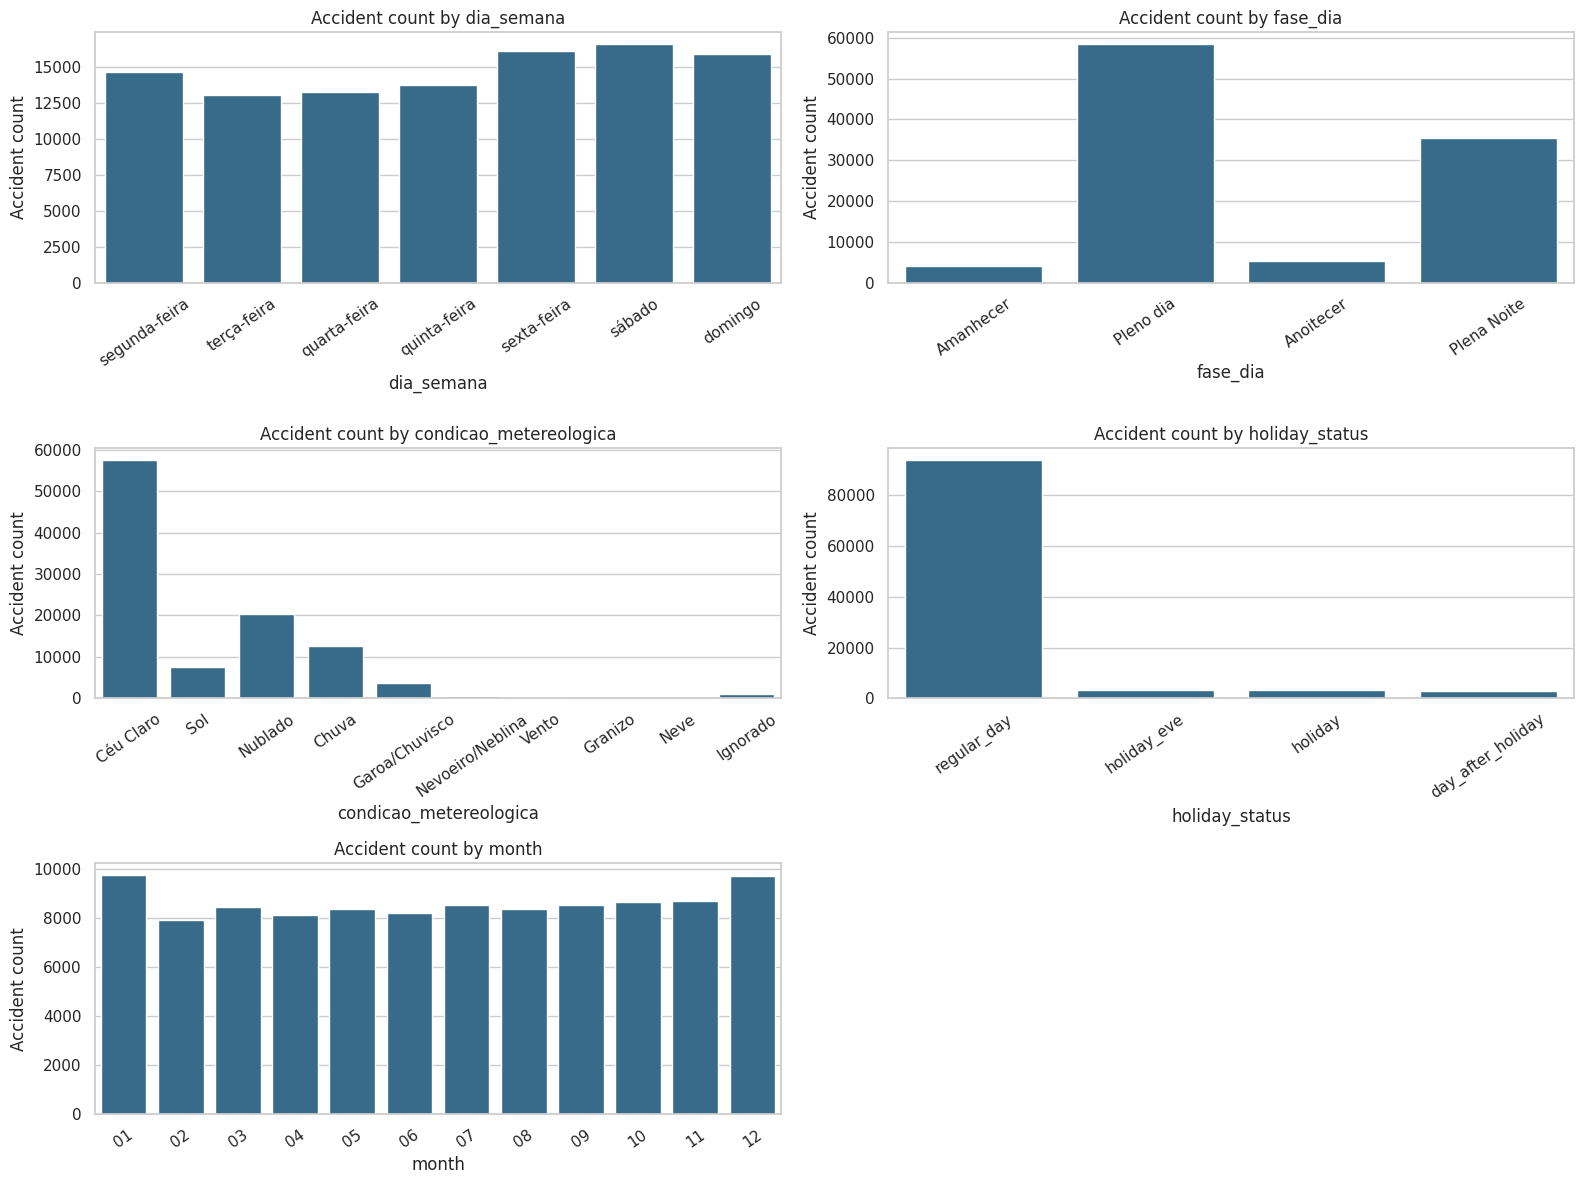

In [7]:
plot_categories = CATEGORY_COLUMNS
ncols = 2
nrows = int(np.ceil(len(plot_categories) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

for axis, category in zip(axes, plot_categories, strict=False):
    plot_df = category_summaries.loc[
        category_summaries["variable"].eq(category) & category_summaries["level_observed"]
    ].copy()
    sns.barplot(data=plot_df, x="level_label", y="accident_count", ax=axis, color="#2a6f97")
    axis.set_title(f"Accident count by {category}")
    axis.set_xlabel(category)
    axis.set_ylabel("Accident count")
    axis.tick_params(axis="x", rotation=35)

for axis in axes[len(plot_categories):]:
    axis.set_visible(False)

plt.tight_layout()
plt.show()

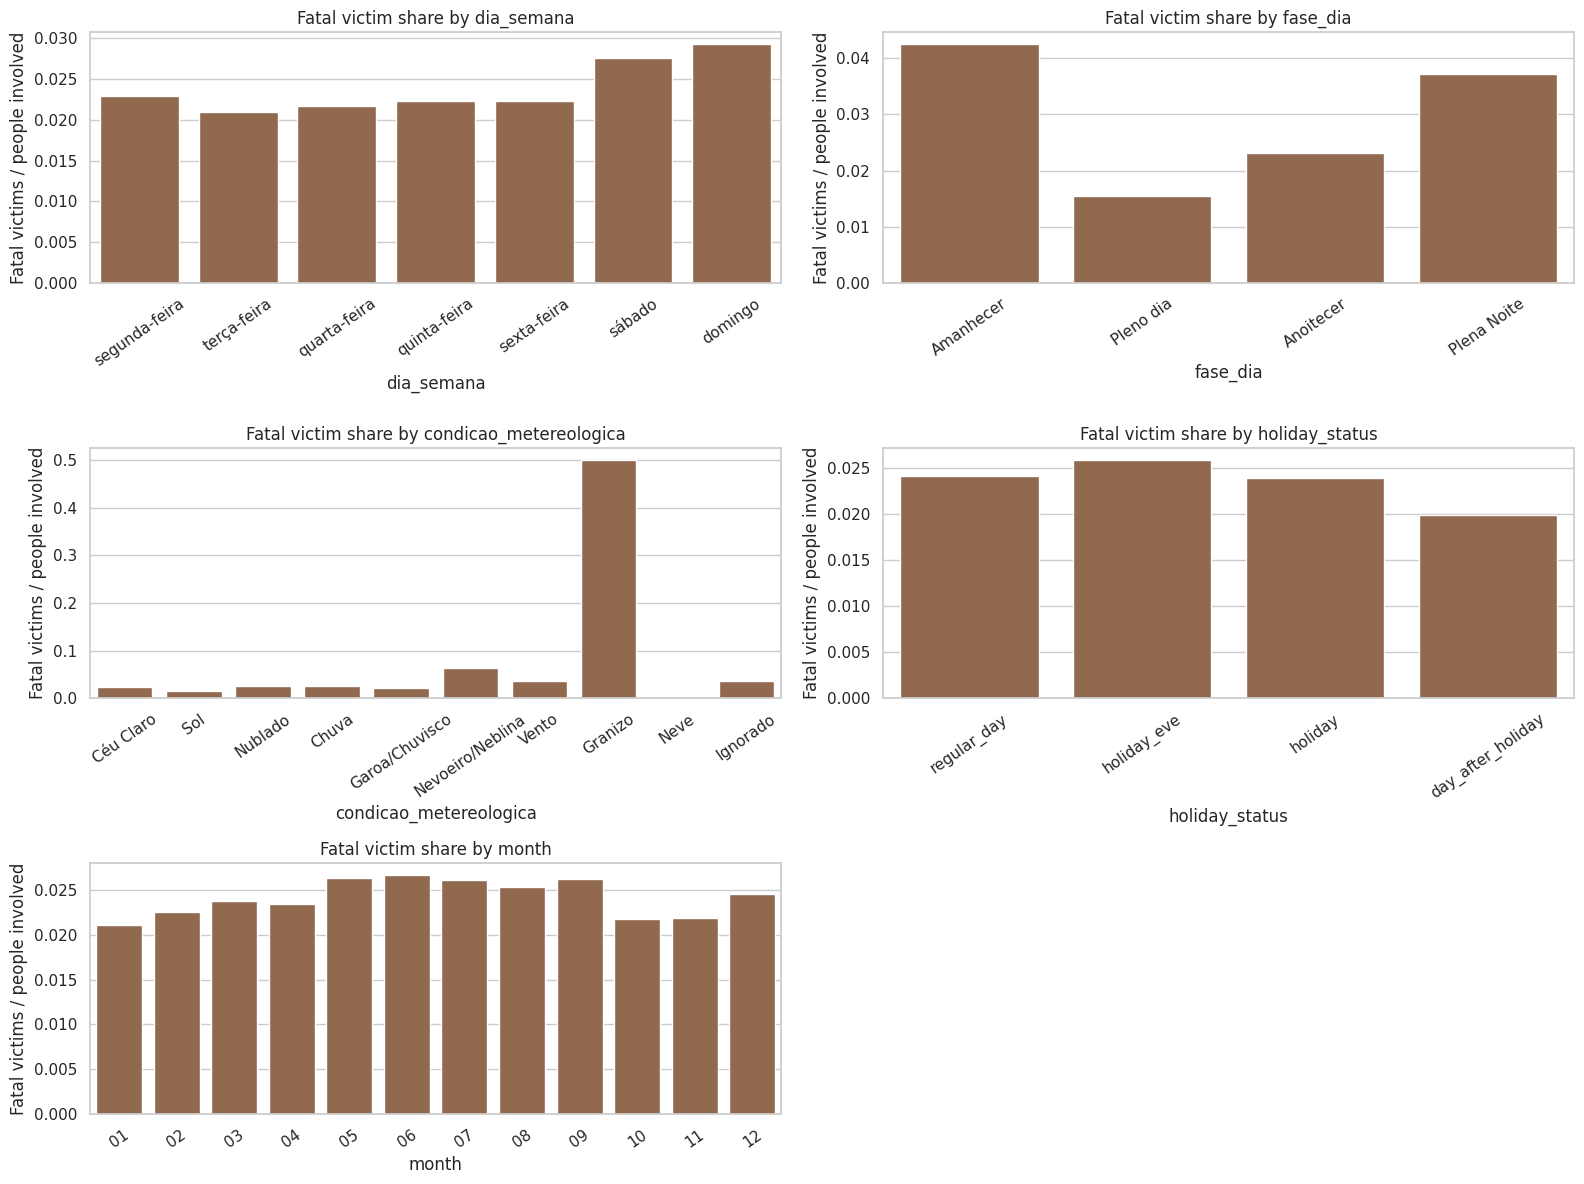

In [9]:
plot_categories = CATEGORY_COLUMNS
ncols = 2
nrows = int(np.ceil(len(plot_categories) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

for axis, category in zip(axes, plot_categories, strict=False):
    plot_df = category_summaries.loc[
        category_summaries["variable"].eq(category) & category_summaries["level_observed"]
    ].copy()
    sns.barplot(
        data=plot_df,
        x="level_label",
        y="fatal_victim_share",
        ax=axis,
        color="#9c6644",
    )
    axis.set_title(f"Fatal victim share by {category}")
    axis.set_xlabel(category)
    axis.set_ylabel("Fatal victims / people involved")
    axis.tick_params(axis="x", rotation=35)

for axis in axes[len(plot_categories):]:
    axis.set_visible(False)

plt.tight_layout()
plt.show()

## Model-ready aggregate tables, dummy-encoding audit, and covariate screening

In [10]:
model_frame = (
    analysis_df.groupby(
        [
            "uf",
            "year",
            "month",
            "dia_semana",
            "fase_dia",
            "condicao_metereologica",
            "holiday_status",
        ],
        dropna=False,
    )
    .agg(
        accident_count=("id", "size"),
        fatal_victims=("mortos", "sum"),
        people_involved=("pessoas", "sum"),
        fatal_accident_count=("has_fatality_occ", "sum"),
    )
    .reset_index()
)
model_frame["fatal_victim_share"] = np.where(
    model_frame["people_involved"] > 0,
    model_frame["fatal_victims"] / model_frame["people_involved"],
    np.nan,
)
model_frame["fatal_accident_share"] = np.where(
    model_frame["accident_count"] > 0,
    model_frame["fatal_accident_count"] / model_frame["accident_count"],
    np.nan,
)

save_frame(model_frame, "step7_model_frame")

reference_categories = choose_reference_categories(model_frame, CATEGORY_COLUMNS)
glm_model_frame = prepare_statsmodels_frame(
    model_frame,
    CATEGORY_COLUMNS,
    category_levels,
    reference_categories,
)
level_support = build_level_support_table(model_frame, CATEGORY_COLUMNS, category_levels)
encoding_audit = build_encoding_audit(
    glm_model_frame,
    CATEGORY_COLUMNS,
    category_levels,
    reference_categories,
    level_support,
)
save_frame(encoding_audit, "step7_dummy_encoding_audit")

encoding_audit

,variable,level_label,reference_level_label,encoding_status,is_observed,grouped_cells,total_accidents,total_people_involved
0,condicao_metereologica,Chuva,Céu Claro,encoded_dummy,True,6610,12541.0,28921.0
1,condicao_metereologica,Garoa/Chuvisco,Céu Claro,encoded_dummy,True,2745,3698.0,8796.0
2,condicao_metereologica,Granizo,Céu Claro,encoded_dummy,True,1,1.0,2.0
3,condicao_metereologica,Ignorado,Céu Claro,encoded_dummy,True,998,1078.0,2285.0
4,condicao_metereologica,Neve,Céu Claro,encoded_dummy,True,1,1.0,1.0
5,condicao_metereologica,Nevoeiro/Neblina,Céu Claro,encoded_dummy,True,425,478.0,1161.0
6,condicao_metereologica,Nublado,Céu Claro,encoded_dummy,True,9324,20231.0,48121.0
7,condicao_metereologica,Sol,Céu Claro,encoded_dummy,True,3938,7464.0,18769.0
8,condicao_metereologica,Vento,Céu Claro,encoded_dummy,True,205,212.0,484.0
9,condicao_metereologica,unknown,Céu Claro,expected_but_unobserved,False,0,0.0,0.0


In [11]:
if sm is None or smf is None:
    print("statsmodels is not installed; skipping optional GLM cells.")
else:
    count_formula = (
        "accident_count ~ C(dia_semana) + C(fase_dia) + "
        "C(condicao_metereologica) + C(holiday_status) + C(month) + C(year) + C(uf)"
    )
    count_model = smf.glm(
        formula=count_formula,
        data=glm_model_frame,
        family=sm.families.Poisson(),
    ).fit()

    count_coefficients = (
        count_model.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    )
    save_frame(count_coefficients, "step7_poisson_coefficients")

    count_coefficients_expanded = augment_coefficient_table(
        count_coefficients,
        encoding_audit,
        CATEGORY_COLUMNS,
    )
    save_frame(count_coefficients_expanded, "step7_poisson_coefficients_expanded")

    count_feature_candidate_summary = build_feature_candidate_summary(
        count_coefficients_expanded,
        encoding_audit,
        outcome_label="count",
    )
    save_frame(count_feature_candidate_summary, "step7_count_feature_candidate_summary")

    print(count_model.summary())
    count_feature_candidate_summary

                 Generalized Linear Model Regression Results                  
Dep. Variable:         accident_count   No. Observations:                41573
Model:                            GLM   Df Residuals:                    41523
Model Family:                 Poisson   Df Model:                           49
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -69569.
Date:                Wed, 25 Mar 2026   Deviance:                       34061.
Time:                        09:53:49   Pearson chi2:                 3.75e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.6695
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [12]:
if sm is None or smf is None:
    print("statsmodels is not installed; skipping optional GLM cells.")
else:
    severity_df = glm_model_frame.loc[glm_model_frame["people_involved"] > 0].copy()
    severity_formula = (
        "fatal_victim_share ~ C(dia_semana) + C(fase_dia) + "
        "C(condicao_metereologica) + C(holiday_status) + C(month) + C(year) + C(uf)"
    )
    severity_model = smf.glm(
        formula=severity_formula,
        data=severity_df,
        family=sm.families.Binomial(),
        freq_weights=severity_df["people_involved"].to_numpy(dtype=float),
    ).fit()

    severity_coefficients = (
        severity_model.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    )
    save_frame(severity_coefficients, "step7_severity_glm_coefficients")

    severity_coefficients_expanded = augment_coefficient_table(
        severity_coefficients,
        encoding_audit,
        CATEGORY_COLUMNS,
    )
    save_frame(
        severity_coefficients_expanded,
        "step7_severity_glm_coefficients_expanded",
    )

    severity_feature_candidate_summary = build_feature_candidate_summary(
        severity_coefficients_expanded,
        encoding_audit,
        outcome_label="severity",
    )
    save_frame(
        severity_feature_candidate_summary,
        "step7_severity_feature_candidate_summary",
    )

    feature_candidate_ranking = build_overall_candidate_ranking(
        count_feature_candidate_summary,
        severity_feature_candidate_summary,
    )
    save_frame(feature_candidate_ranking, "step7_feature_candidate_ranking")

    print(severity_model.summary())
    feature_candidate_ranking

                 Generalized Linear Model Regression Results                  
Dep. Variable:     fatal_victim_share   No. Observations:                41573
Model:                            GLM   Df Residuals:                   247922
Model Family:                Binomial   Df Model:                           49
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -22400.
Date:                Wed, 25 Mar 2026   Deviance:                       23134.
Time:                        09:53:59   Pearson chi2:                 4.70e+04
No. Iterations:                    19   Pseudo R-squ. (CS):            0.06463
Covariance Type:            nonrobust                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [13]:
feature_candidate_ranking

,variable,count_reference_level,count_observed_levels,count_dummy_levels,count_unobserved_expected_levels,count_significant_levels_p01,count_significant_levels_p05,count_max_abs_pct_change_vs_reference,count_sparse_level_share,count_candidate_tier,count_candidate_score,severity_reference_level,severity_observed_levels,severity_dummy_levels,severity_unobserved_expected_levels,severity_significant_levels_p01,severity_significant_levels_p05,severity_max_abs_pct_change_vs_reference,severity_sparse_level_share,severity_candidate_tier,severity_candidate_score,reference_level,overall_candidate_score,overall_candidate_tier,automatic_conclusion
0,condicao_metereologica,Céu Claro,10,9,1,7,7,0.749119,0.3,strong,3,Céu Claro,10,9,1,2,4,32.432647,0.3,strong,3,Céu Claro,6,high_priority,retain for both count and severity models
1,fase_dia,Pleno dia,4,3,1,3,3,0.710698,0.0,strong,3,Pleno dia,4,3,1,3,3,1.515356,0.0,strong,3,Pleno dia,6,high_priority,retain for both count and severity models
2,month,11,12,11,0,10,10,0.212190,0.0,strong,3,11,12,11,0,0,3,0.147350,0.0,moderate,2,11,5,high_priority,retain for both count and severity models
3,dia_semana,domingo,7,6,1,5,5,0.108826,0.0,moderate,2,domingo,7,6,1,4,5,0.165094,0.0,strong,3,domingo,5,high_priority,retain for both count and severity models
4,holiday_status,regular_day,4,3,1,3,3,0.479284,0.0,strong,3,regular_day,4,3,1,0,0,0.146507,0.0,weak,1,regular_day,4,promising,retain selectively and check sparse levels bef...
